# Getting Started: Bayesian Workflow with ProbPipe

This tutorial walks through an iterative Bayesian modeling workflow using ProbPipe, following the principles outlined in [Bayesian Workflow](https://arxiv.org/abs/2011.01808) (Gelman et al., 2020). The key idea is that applied Bayesian analysis is *iterative*: we start with a simple model, check it against data, revise, and repeat.

### ProbPipe's approach

Most workflows for probabilistic inference can be described in terms of four **abstract components**:

1. **Distributions** — priors, posteriors, data products.
2. **Fixed inputs** — data and hyperparameters.
3. **Operations** that transform distributions — conditioning, pushforwards, expectations.
4. **Differentiation** with respect to fixed inputs.

Implementing these workflows, however, is harder than describing them:

- **Algorithmic challenges** — many possible algorithms exist for the same operation. A posterior could be approximated using different MCMC algorithms, variational inference, or sequential Monte Carlo. These are implemented across many packages and often not designed to be directly compatible.
- **Representational challenges** — algorithms require or output specific distribution formats that may not be compatible with other parts of the workflow. For example, MCMC outputs a discrete approximation to a distribution, but many MCMC algorithms require continuous parametric priors.

ProbPipe manages representations and algorithms automatically by default, while giving you control over these choices when you want it:

- **`Distribution`s** support subsets of capabilities via protocols (`SupportsSampling`, `SupportsLogProb`, ...) — ProbPipe converts between representations as needed, or you can choose a specific representation explicitly.
- **`WorkflowFunction`s** compute pushforward distributions automatically — you write a function that takes fixed values, and ProbPipe propagates uncertainty when those values are in fact unknown.
- **`condition_on`** selects an appropriate inference algorithm automatically, but you can specify the algorithm, backend, or tuning parameters directly.
- **`predictive_check`** provides built-in prior and posterior predictive checking.

### The dataset

We use the **horseshoe crab satellite** dataset (Brockmann, 1996; Agresti, 2007). Each nesting female horseshoe crab may attract "satellite" males. The response is the **count of satellites**, with the female's **carapace width** (cm) as the primary covariate. This is count data with overdispersion and excess zeros — a natural setting for iterative model building.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype.*float64.*")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    Normal, MultivariateNormal, EmpiricalDistribution,
    BootstrapReplicateDistribution,
    SimpleModel, condition_on, from_distribution,
    sample, mean, variance, log_prob,
    workflow_function, predictive_check,
    provenance_ancestors,
)
from probpipe.modeling import Likelihood, GenerativeLikelihood, IncrementalConditioner

rng = np.random.default_rng(42)

# -- Horseshoe crab data (Brockmann 1996, Agresti 2007) --
# Columns: carapace width (cm), number of satellites
_raw = np.array([
    [28.3, 8], [22.5, 0], [26.0, 9], [24.8, 0], [26.0, 4], [23.8, 0],
    [26.5, 0], [24.7, 0], [23.7, 0], [25.6, 0], [24.3, 0], [25.8, 0],
    [28.2,11], [21.0, 0], [26.0,14], [27.1, 8], [25.2, 1], [29.0, 1],
    [24.7, 0], [27.4, 5], [23.2, 4], [25.0, 3], [22.5, 1], [26.7, 2],
    [25.8, 3], [26.2, 0], [28.7, 3], [26.8, 5], [27.5, 0], [24.9, 0],
    [29.3, 4], [25.8, 0], [25.7, 0], [25.7, 8], [26.7, 5], [23.7, 0],
    [26.8, 0], [27.5, 6], [23.4, 0], [27.9, 6], [27.5, 3], [26.1, 5],
    [27.7, 6], [30.0, 5], [28.5, 9], [28.9, 4], [28.2, 6], [25.0, 4],
    [28.5, 3], [30.3, 3], [24.7, 5], [27.7, 5], [27.4, 6], [22.9, 4],
    [25.7, 5], [28.3,15], [27.2, 3], [26.2, 3], [27.8, 0], [25.5, 0],
    [27.1, 0], [24.5, 5], [27.0, 3], [26.0, 5], [28.0, 1], [30.0, 8],
    [29.0,10], [26.2, 0], [26.5, 0], [26.2, 3], [25.6, 7], [23.0, 1],
    [23.0, 0], [25.4, 6], [24.2, 0], [22.9, 0], [26.0, 3], [25.4, 4],
    [25.7, 0], [25.1, 5], [24.5, 0], [27.5, 0], [23.1, 0], [25.9, 4],
    [25.8, 0], [27.0, 3], [28.5, 0], [25.5, 0], [23.5, 0], [24.0, 0],
    [29.7, 5], [26.8, 0], [26.7, 0], [28.7, 0], [23.1, 0], [29.0, 1],
    [25.5, 0], [26.5, 1], [24.5, 1], [28.5, 1], [28.2, 1], [24.5, 1],
    [27.5, 1], [24.7, 4], [25.2, 1], [27.3, 1], [26.3, 1], [29.0, 1],
    [25.3, 2], [26.5, 4], [27.8, 3], [27.0, 6], [25.7, 0], [25.0, 2],
    [31.9, 2], [23.7, 0], [29.3,12], [22.0, 0], [25.0, 5], [27.0, 6],
    [23.8, 6], [30.2, 2], [26.2, 0], [24.2, 2], [27.4, 3], [25.4, 0],
    [28.4, 3], [22.5, 4], [26.2, 2], [24.9, 6], [24.5, 6], [25.1, 0],
    [28.0, 4], [25.8,10], [27.9, 7], [24.9, 0], [28.4, 5], [27.2, 5],
    [25.0, 6], [27.5, 6], [33.5, 7], [30.5, 3], [29.0, 3], [24.3, 0],
    [25.8, 0], [25.0, 8], [31.7, 4], [29.5, 4], [24.0,10], [30.0, 9],
    [27.6, 4], [26.2, 0], [23.1, 0], [22.9, 0], [24.5, 0], [24.7, 4],
    [28.3, 0], [23.9, 2], [23.8, 0], [29.8, 4], [26.5, 4], [26.0, 3],
    [28.2, 8], [25.7, 0], [26.5, 7], [25.8, 0], [24.1, 0], [26.2, 2],
    [26.1, 3], [29.0, 4], [28.0, 0], [27.0, 0], [24.5, 0],
], dtype=np.float32)

x_width = _raw[:, 0]   # carapace width (cm)
y_sat = _raw[:, 1]     # satellite count

# Center the covariate for better MCMC behavior
x_mean = float(np.mean(x_width))
x_centered = x_width - x_mean

print(f"n = {len(y_sat)} crabs")
print(f"Satellite counts: mean = {y_sat.mean():.2f}, "
      f"var = {y_sat.var():.2f}, "
      f"zeros = {int(np.sum(y_sat == 0))}/{len(y_sat)}")

n = 173 crabs
Satellite counts: mean = 2.92, var = 9.85, zeros = 62/173


## 1. Choose an initial model

Following the Bayesian Workflow, we start simple. A **Poisson regression** is the natural first model for count data:

$$y_i \sim \text{Poisson}(\exp(\beta_0 + \beta_1 \, x_i))$$

where $x_i$ is the centered carapace width. In ProbPipe, a model is assembled from a **prior** and a **likelihood**. Any class with a `log_likelihood(params, data)` method satisfies the `Likelihood` protocol — no base class needed. Adding `generate_data(params, n_samples)` additionally satisfies `GenerativeLikelihood`, which enables predictive checks.

In [2]:
class PoissonRegression:
    """Poisson regression satisfying both Likelihood and GenerativeLikelihood."""

    def __init__(self, x):
        self._x = jnp.asarray(x, dtype=jnp.float32)

    def log_likelihood(self, params, data):
        log_rate = params[0] + params[1] * self._x
        rate = jnp.exp(log_rate)
        return jnp.sum(data * log_rate - rate - jax.scipy.special.gammaln(data + 1))

    def generate_data(self, params, n_samples):
        log_rate = params[0] + params[1] * self._x[:n_samples]
        rate = jnp.exp(log_rate)
        return jax.random.poisson(jax.random.PRNGKey(rng.integers(2**31)), rate)


likelihood_poisson = PoissonRegression(x_centered)

In [3]:
prior = MultivariateNormal(
    loc=jnp.zeros(2), cov=5.0 * jnp.eye(2), name="prior"
)
model_poisson = SimpleModel(prior, likelihood_poisson, name="poisson")
print(model_poisson)

SimpleModel(prior=MultivariateNormal, likelihood=PoissonRegression)


## 2. Prior predictive checking

Before fitting, we check whether the prior implies plausible data. ProbPipe's `predictive_check` draws parameter samples from the prior, generates replicated data, and computes a summary statistic on each replicate. Without `observed_data`, it acts as a **prior predictive check**.

In [4]:
prior_check = predictive_check(
    prior, likelihood_poisson,
    test_fn=lambda d: float(jnp.mean(d)),
    n_samples=len(y_sat),
    n_replications=200,
    key=jax.random.PRNGKey(0),
)

prior_means = np.array(prior_check["replicated_statistics"].samples)
print(f"Prior predictive mean counts: "
      f"median = {np.median(prior_means):.1f}, "
      f"90th pct = {np.percentile(prior_means, 90):.1f}, "
      f"max = {np.max(prior_means):.0f}")
print(f"Observed mean count: {float(y_sat.mean()):.2f}")

Prior predictive mean counts: median = 241.3, 90th pct = 14696515.0, max = 115660008
Observed mean count: 2.92


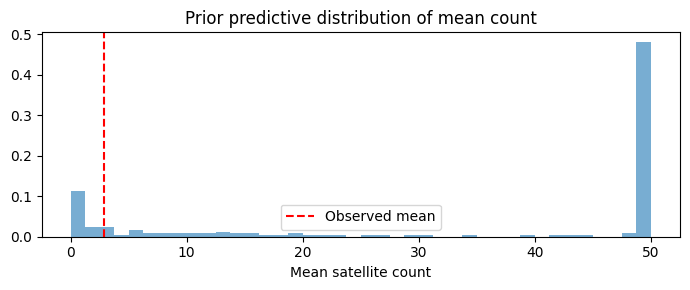

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.clip(prior_means, 0, 50), bins=40, density=True, alpha=0.6)
ax.axvline(float(y_sat.mean()), color="red", linestyle="--", label="Observed mean")
ax.set_xlabel("Mean satellite count")
ax.set_title("Prior predictive distribution of mean count")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Fit the model (MCMC)

`condition_on(model, data)` runs MCMC to approximate the posterior. ProbPipe auto-detects JAX traceability and uses **NUTS** (gradient-based) when possible, falling back to **RWMH** (gradient-free) otherwise. The result is an `MCMCApproximateDistribution` — an empirical distribution that preserves chain structure and diagnostics.

In [6]:
posterior_poisson = condition_on(
    model_poisson, jnp.asarray(y_sat),
    num_results=2000, num_warmup=1000, random_seed=0,
)
print(f"Posterior mean:  {mean(posterior_poisson)}")
print(f"Posterior stdev: {jnp.sqrt(variance(posterior_poisson))}")

Posterior mean:  [1.0054964 0.1644235]
Posterior stdev: [0.04709756 0.02003996]


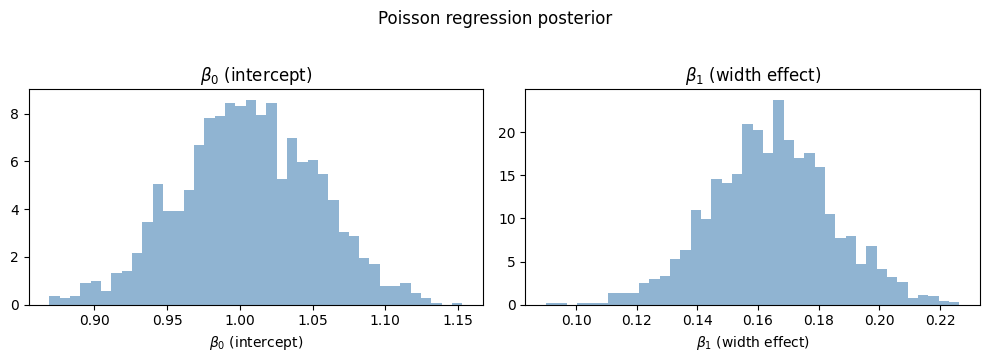

In [7]:
draws = np.array(posterior_poisson.draws())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, j, name in [(ax1, 0, r"$\beta_0$ (intercept)"), (ax2, 1, r"$\beta_1$ (width effect)")]:
    ax.hist(draws[:, j], bins=40, density=True, alpha=0.6, color="steelblue")
    ax.set_xlabel(name)
    ax.set_title(name)
plt.suptitle("Poisson regression posterior", y=1.02)
plt.tight_layout()
plt.show()

## 4. Check MCMC diagnostics

The Bayesian Workflow insists on checking MCMC convergence before trusting results. Every `MCMCApproximateDistribution` stores diagnostics — acceptance rate, step size, divergences, and more.

In [8]:
diag = posterior_poisson.diagnostics
print(f"Algorithm:      {diag.algorithm}")
print(f"Accept rate:    {diag.accept_rate:.3f}")
print(f"Step size:      {diag.final_step_size:.4f}")
if "diverging" in diag:
    print(f"Divergences:    {int(jnp.sum(diag['diverging']))}")
print(f"\nFull summary: {diag.summary()}")

Algorithm:      nuts
Accept rate:    0.904
Step size:      0.0272

Full summary: algorithm=nuts, accept_rate=0.904, final_step_size=0.0272


## 5. Posterior predictive checking

Now we check whether the fitted model can reproduce key features of the observed data. When `observed_data` is provided, `predictive_check` computes the test statistic on the observed data and returns a **calibration p-value**.

A key feature of count data is the **variance-to-mean ratio**. For a Poisson distribution this ratio is 1, but the observed data show a ratio much larger than 1 — overdispersion.

In [9]:
def var_mean_ratio(data):
    """Variance-to-mean ratio — 1 for Poisson, >1 for overdispersion."""
    return float(jnp.var(data) / jnp.maximum(jnp.mean(data), 1e-6))

def zero_fraction(data):
    """Fraction of zeros in the data."""
    return float(jnp.mean(data == 0))

ppc_vmr = predictive_check(
    posterior_poisson, likelihood_poisson,
    test_fn=var_mean_ratio,
    observed_data=jnp.asarray(y_sat),
    n_replications=500,
    key=jax.random.PRNGKey(1),
)

ppc_zeros = predictive_check(
    posterior_poisson, likelihood_poisson,
    test_fn=zero_fraction,
    observed_data=jnp.asarray(y_sat),
    n_replications=500,
    key=jax.random.PRNGKey(2),
)

print(f"Variance/mean ratio — observed: {ppc_vmr['observed_statistic']:.2f}, "
      f"p-value: {ppc_vmr['p_value']:.3f}")
print(f"Zero fraction     — observed: {ppc_zeros['observed_statistic']:.2f}, "
      f"p-value: {ppc_zeros['p_value']:.3f}")

Variance/mean ratio — observed: 3.38, p-value: 0.000
Zero fraction     — observed: 0.36, p-value: 0.000


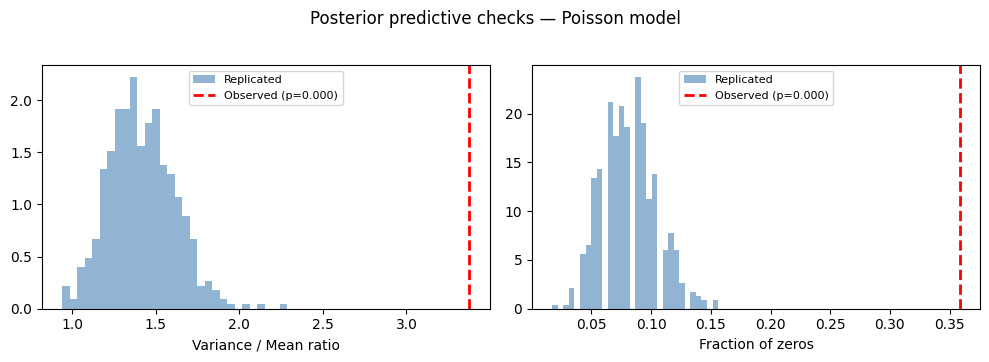

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, check, label in [
    (ax1, ppc_vmr, "Variance / Mean ratio"),
    (ax2, ppc_zeros, "Fraction of zeros"),
]:
    stats = np.array(check["replicated_statistics"].samples)
    ax.hist(stats, bins=30, density=True, alpha=0.6, color="steelblue",
            label="Replicated")
    ax.axvline(check["observed_statistic"], color="red", linestyle="--",
               linewidth=2, label=f"Observed (p={check['p_value']:.3f})")
    ax.set_xlabel(label)
    ax.legend(fontsize=8)

plt.suptitle("Posterior predictive checks — Poisson model", y=1.02)
plt.tight_layout()
plt.show()

The variance-to-mean ratio check **fails** — the observed data are far more overdispersed than the Poisson model can produce. This motivates a model revision.

## 6. Modify the model — swap the likelihood

When a check fails, the Bayesian Workflow says: revise the model. ProbPipe's modular design makes this easy — we define a new likelihood class and rebuild the model. The **negative binomial** distribution naturally handles overdispersion by adding a dispersion parameter.

In [11]:
class NegBinRegression:
    """Negative binomial regression (Likelihood + GenerativeLikelihood).

    params = [beta_0, beta_1, log_r] where r is the dispersion.
    """

    def __init__(self, x):
        self._x = jnp.asarray(x, dtype=jnp.float32)

    def log_likelihood(self, params, data):
        log_mu = params[0] + params[1] * self._x
        mu = jnp.exp(log_mu)
        r = jnp.exp(params[2])  # dispersion > 0
        return jnp.sum(
            jax.scipy.special.gammaln(data + r)
            - jax.scipy.special.gammaln(r)
            - jax.scipy.special.gammaln(data + 1)
            + r * jnp.log(r / (r + mu))
            + data * jnp.log(mu / (r + mu))
        )

    def generate_data(self, params, n_samples):
        log_mu = params[0] + params[1] * self._x[:n_samples]
        mu = jnp.exp(log_mu)
        r = jnp.exp(params[2])
        # NegBin as Poisson-Gamma mixture: lambda ~ Gamma(r, r/mu), y ~ Poisson(lambda)
        key1, key2 = jax.random.split(jax.random.PRNGKey(rng.integers(2**31)))
        lam = jax.random.gamma(key1, r, shape=(n_samples,)) * (mu / r)
        return jax.random.poisson(key2, lam)


likelihood_nb = NegBinRegression(x_centered)

# 3 parameters now: beta_0, beta_1, log(r)
prior_nb = MultivariateNormal(
    loc=jnp.zeros(3), cov=5.0 * jnp.eye(3), name="prior_nb"
)
model_nb = SimpleModel(prior_nb, likelihood_nb, name="negbin")

In [12]:
posterior_nb = condition_on(
    model_nb, jnp.asarray(y_sat),
    num_results=2000, num_warmup=1000, random_seed=1,
)
print(f"NegBin posterior mean:  {mean(posterior_nb)}")
print(f"Diagnostics: {posterior_nb.diagnostics.summary()}")

# Rerun the variance-to-mean check
ppc_nb = predictive_check(
    posterior_nb, likelihood_nb,
    test_fn=var_mean_ratio,
    observed_data=jnp.asarray(y_sat),
    n_replications=500,
    key=jax.random.PRNGKey(3),
)
print(f"\nVariance/mean ratio — p-value: {ppc_nb['p_value']:.3f} "
      f"(was {ppc_vmr['p_value']:.3f} for Poisson)")

NegBin posterior mean:  [ 0.99961615  0.19474763 -0.11805715]
Diagnostics: algorithm=nuts, accept_rate=0.951, final_step_size=0.0698



Variance/mean ratio — p-value: 0.974 (was 0.000 for Poisson)


## 7. Compare multiple models

ProbPipe's modular design means comparing models is just overlaying posteriors — the same pipeline, different likelihoods.

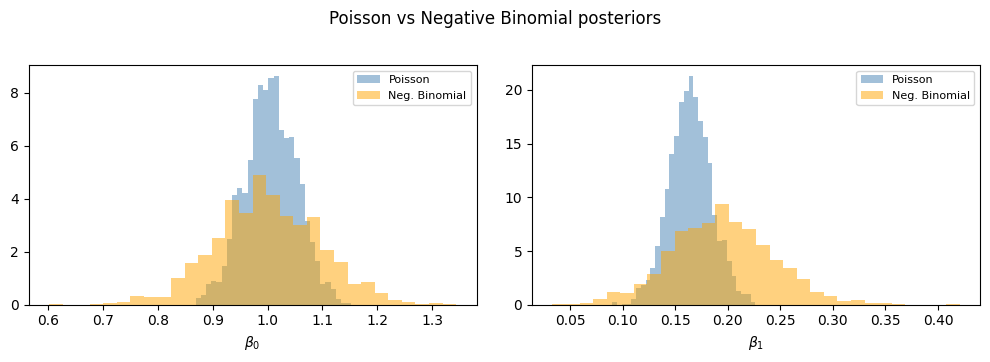

In [13]:
draws_p = np.array(posterior_poisson.draws())
draws_nb = np.array(posterior_nb.draws())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, j, name in [(ax1, 0, r"$\beta_0$"), (ax2, 1, r"$\beta_1$")]:
    ax.hist(draws_p[:, j], bins=30, density=True, alpha=0.5,
            color="steelblue", label="Poisson")
    ax.hist(draws_nb[:, j], bins=30, density=True, alpha=0.5,
            color="orange", label="Neg. Binomial")
    ax.set_xlabel(name)
    ax.legend(fontsize=8)
plt.suptitle("Poisson vs Negative Binomial posteriors", y=1.02)
plt.tight_layout()
plt.show()

## 8. Bagged posteriors for reproducible inference

Under model misspecification, standard Bayesian posteriors can be unreliable — credible sets from replicate datasets may not overlap. The **bagged posterior** ([Huggins & Miller, 2024](https://doi.org/10.1214/24-EJS2237)) averages over posteriors conditioned on bootstrapped datasets, yielding reproducible uncertainty quantification.

ProbPipe makes this natural: `BootstrapReplicateDistribution` wraps the data as a distribution over bootstrap datasets. Broadcasting `condition_on` over it produces the bagged posterior.

In [14]:
bootstrap_data = BootstrapReplicateDistribution(
    EmpiricalDistribution(jnp.asarray(y_sat))
)

# Broadcasting: condition_on draws bootstrap datasets and runs MCMC on each
bagged_posterior = condition_on(
    model_nb, bootstrap_data,
    num_results=500, num_warmup=300, random_seed=42,
)
print(f"Bagged posterior: {bagged_posterior}")
print(f"Number of bootstrap components: {len(bagged_posterior.components)}")

Bagged posterior: MarginalizedBroadcastDistribution(mixture, n=128)
Number of bootstrap components: 128


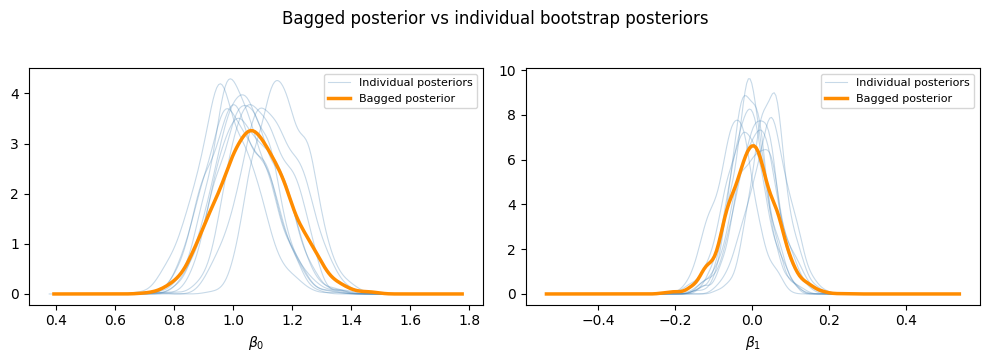

In [15]:
from scipy.stats import gaussian_kde

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, j, name in [(ax1, 0, r"$\beta_0$"), (ax2, 1, r"$\beta_1$")]:
    # Individual bootstrap posteriors
    for i, post in enumerate(bagged_posterior.components[:10]):
        d = np.array(post.samples[:, j])
        kde = gaussian_kde(d)
        xs = np.linspace(d.min() - 0.3, d.max() + 0.3, 200)
        ax.plot(xs, kde(xs), alpha=0.3, lw=0.8, color="steelblue",
                label="Individual posteriors" if i == 0 else None)

    # Bagged posterior
    bagged_draws = np.array(sample(
        bagged_posterior, sample_shape=(2000,), key=jax.random.PRNGKey(99)
    )[:, j])
    kde_bag = gaussian_kde(bagged_draws)
    xs = np.linspace(bagged_draws.min() - 0.3, bagged_draws.max() + 0.3, 200)
    ax.plot(xs, kde_bag(xs), color="darkorange", lw=2.5, label="Bagged posterior")
    ax.set_xlabel(name)
    ax.legend(fontsize=8)

plt.suptitle("Bagged posterior vs individual bootstrap posteriors", y=1.02)
plt.tight_layout()
plt.show()

## 9. Sequential updating with new data

`IncrementalConditioner` automates sequential Bayesian updating: each new data batch updates the posterior, which becomes the prior for the next batch. Since MCMC needs a prior with a computable density, we use `from_distribution` to convert the empirical posterior to a `MultivariateNormal` approximation via the converter registry.

In [16]:
# Split data: first 80 for initial fit, rest in 2 batches
n_init = 80
x_init, y_init = x_centered[:n_init], y_sat[:n_init]
batches = [
    (x_centered[80:130], y_sat[80:130]),
    (x_centered[130:], y_sat[130:]),
]

# Initial fit
lik_init = NegBinRegression(x_init)
model_init = SimpleModel(prior_nb, lik_init)
post_init = condition_on(model_init, jnp.asarray(y_init),
                         num_results=1000, num_warmup=500, random_seed=10)

# Convert to parametric approximation for use as a prior
approx = from_distribution(post_init, MultivariateNormal, name="approx")

def gaussian_condition(model, data):
    post = model._condition_on(data, num_results=500, num_warmup=300, random_seed=0)
    return from_distribution(post, MultivariateNormal, name="posterior")

conditioner = IncrementalConditioner(
    prior=approx,
    likelihood=NegBinRegression(batches[0][0]),
    condition_fn=gaussian_condition,
)

total_n = n_init
posteriors_seq = [approx]
for i, (x_batch, y_batch) in enumerate(batches):
    conditioner._likelihood = NegBinRegression(x_batch)
    post = conditioner.update(data=jnp.asarray(y_batch))
    posteriors_seq.append(post)
    total_n += len(y_batch)
    print(f"Batch {i+1} (n_total={total_n}): posterior mean = {mean(post)}")

Batch 1 (n_total=130): posterior mean = [ 0.9646756   0.21088485 -0.07204136]


Batch 2 (n_total=173): posterior mean = [ 0.99628365  0.18967848 -0.07410886]


## 10. Propagate posterior uncertainty downstream

When a `@workflow_function` receives a distribution where it expects a concrete value, ProbPipe automatically **broadcasts** over samples — you write a deterministic function and get uncertainty quantification for free.

In [17]:
@workflow_function
def predict_rate(params, x):
    """Predicted rate: exp(beta_0 + beta_1 * x)."""
    return jnp.exp(params[0] + params[1] * x)

# Pass the posterior as params — broadcasting handles sampling automatically
x_test = 0.0  # mean-width crab
rate_dist = predict_rate(params=posterior_nb, x=x_test)
print(f"Predicted rate at mean width: {float(mean(rate_dist)):.2f} "
      f"(+/- {float(jnp.sqrt(variance(rate_dist))):.2f})")

Predicted rate at mean width: 2.75 (+/- 0.26)


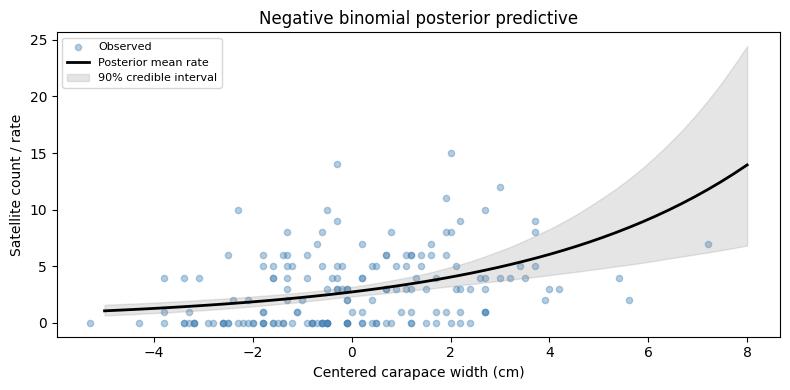

In [18]:
x_grid = jnp.linspace(-5, 8, 50)
draws_nb = np.array(posterior_nb.draws())

rates = np.exp(draws_nb[:, 0:1] + draws_nb[:, 1:2] * np.array(x_grid)[None, :])
rate_mean = np.mean(rates, axis=0)
rate_lo = np.percentile(rates, 5, axis=0)
rate_hi = np.percentile(rates, 95, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_centered, y_sat, alpha=0.4, s=20, color="steelblue",
           label="Observed")
ax.plot(x_grid, rate_mean, "k-", lw=2, label="Posterior mean rate")
ax.fill_between(x_grid, rate_lo, rate_hi, alpha=0.2, color="gray",
                label="90% credible interval")
ax.set_xlabel("Centered carapace width (cm)")
ax.set_ylabel("Satellite count / rate")
ax.set_title("Negative binomial posterior predictive")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 11. Provenance tracking

Every distribution in ProbPipe records how it was created — the algorithm, parents, and metadata. This enables full lineage tracing from any result back to its inputs.

In [19]:
print(f"Source: {posterior_nb.source}")
print(f"Algorithm: {posterior_nb.source.metadata['algorithm']}")

ancestors = provenance_ancestors(posterior_nb)
print(f"\nAncestors: {[type(a).__name__ + (f'({a.name})' if a.name else '') for a in ancestors]}")

Source: Provenance('nuts', parents=[prior_nb])
Algorithm: nuts

Ancestors: ['MultivariateNormal(prior_nb)']


## 12. Using external model-building tools

ProbPipe integrates with external probabilistic programming tools. The same `condition_on` interface works regardless of backend:

- **PyMC** — wrap a PyMC model function as `PyMCModel`:
  ```python
  import pymc as pm
  from probpipe.modeling import PyMCModel

  def poisson_model(y=None):
      with pm.Model() as m:
          beta = pm.Normal("beta", 0, 3, shape=2)
          rate = pm.math.exp(beta[0] + beta[1] * x_centered)
          pm.Poisson("y", mu=rate, observed=y)
      return m

  pymc_model = PyMCModel(poisson_model)
  posterior_pymc = condition_on(pymc_model, y_sat)
  ```

- **Stan** — wrap a `.stan` file as `StanModel` (requires BridgeStan + CmdStanPy):
  ```python
  from probpipe.modeling import StanModel
  stan_model = StanModel("poisson_reg.stan", data={"N": len(y_sat), "x": x_centered})
  posterior_stan = condition_on(stan_model, {"y": y_sat})
  ```

- **nutpie** — alternative NUTS backend via Rust:
  ```python
  from probpipe.inference import condition_on_nutpie
  posterior_nutpie = condition_on_nutpie(model_poisson, y_sat, num_results=2000)
  ```

In all cases, the result is an `MCMCApproximateDistribution` that plugs into the same downstream workflow — broadcasting, predictive checks, provenance.

## 13. Summary

| Workflow Step | ProbPipe Feature |
|---|---|
| Choose initial model | `Likelihood` protocol + `SimpleModel` |
| Prior predictive check | `predictive_check(prior, ...)` |
| Fit (MCMC) | `condition_on(model, data)` |
| Check diagnostics | `MCMCApproximateDistribution.diagnostics` |
| Posterior predictive check | `predictive_check(posterior, ..., observed_data=...)` |
| Modify model | Swap likelihood class, rebuild `SimpleModel` |
| Compare models | Same pipeline, different likelihoods |
| Bagged posteriors | `BootstrapReplicateDistribution` + broadcasting |
| Sequential updating | `IncrementalConditioner` + `from_distribution` |
| Propagate uncertainty | `@workflow_function` broadcasting |
| External tools | `PyMCModel`, `StanModel`, `condition_on_nutpie` |
| Track lineage | `Provenance`, `provenance_ancestors` |

### References

- Gelman, A., Vehtari, A., Simpson, D., et al. (2020). [Bayesian Workflow](https://arxiv.org/abs/2011.01808). *arXiv:2011.01808*.
- Brockmann, H.J. (1996). Satellite male groups in horseshoe crabs, *Limulus polyphemus*. *Ethology*, 102(1), 1–21.
- Huggins, J.H. & Miller, J.W. (2024). [Reproducible Model Selection Using Bagged Posteriors](https://doi.org/10.1214/24-EJS2237). *Electronic Journal of Statistics*.

### Next steps

- [API Reference](../api/distributions.md) — full class and function documentation
- [Reference Notebooks](../reference_notebooks.md) — in-depth coverage of distributions, broadcasting, joint models, autodiff, and more